# Task 3 — Correlation Between News Sentiment and Stock Movement

## Objective
This notebook analyzes the relationship between financial news sentiment and stock price movements.

The workflow includes:
- Loading financial news data
- Loading stock market data
- Performing sentiment analysis
- Calculating daily returns
- Correlation analysis
- Visualization and interpretation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob

In [3]:
news = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

news.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [4]:
aapl = pd.read_csv("../data/raw/AAPL.csv")

aapl.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


News Data Loaded Successfully!
      Unnamed: 0                                           headline  \
6680        7120  Tech Stocks And FAANGS Strong Again To Start D...   
6681        7121      10 Biggest Price Target Changes For Wednesday   
6682        7122  Benzinga Pro's Top 5 Stocks To Watch For Wed.,...   
6683        7123  Deutsche Bank Maintains Buy on Apple, Raises P...   
6684        7124  Apple To Let Users Trade In Their Mac Computer...   

                                                    url          publisher  \
6680  https://www.benzinga.com/government/20/06/1622...         JJ Kinahan   
6681  https://www.benzinga.com/analyst-ratings/price...         Lisa Levin   
6682  https://www.benzinga.com/short-sellers/20/06/1...  Benzinga Newsdesk   
6683  https://www.benzinga.com/news/20/06/16219873/d...  Benzinga Newsdesk   
6684  https://www.benzinga.com/news/20/06/16218697/a...      Neer Varshney   

                           date stock  
6680  2020-06-10 11:33:26-04:00  

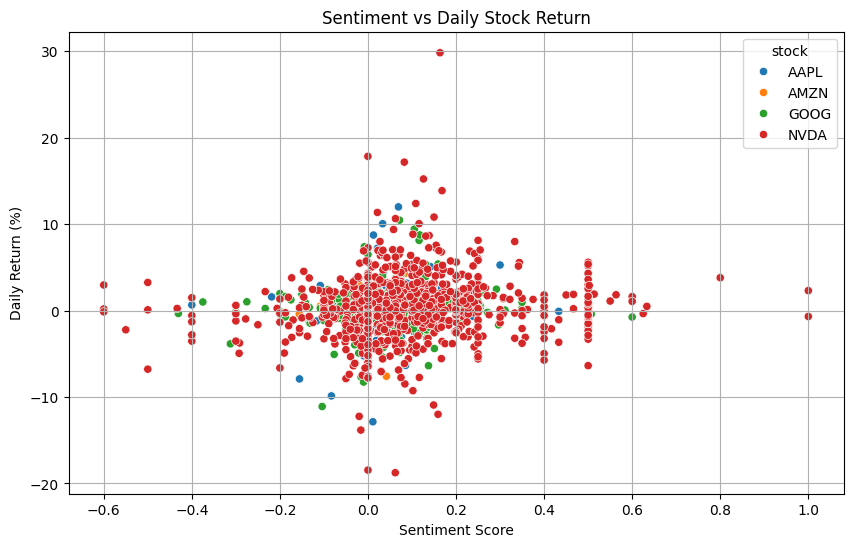

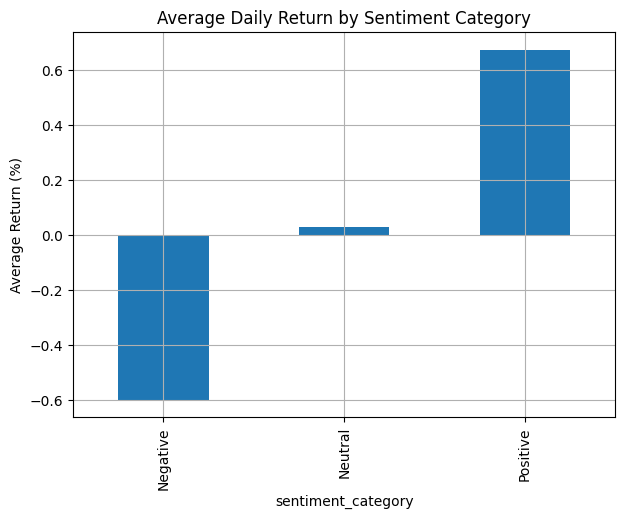


TASK 3 COMPLETED SUCCESSFULLY!


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

# =========================================
# LOAD NEWS DATA
# =========================================

news = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

# Stocks we are analyzing
stocks = ["AAPL", "AMZN", "GOOG", "META", "NVDA"]

# Keep only those stocks
news = news[news["stock"].isin(stocks)]

print("News Data Loaded Successfully!")
print(news.head())

# =========================================
# CLEAN NEWS DATA
# =========================================

news["date"] = pd.to_datetime(
    news["date"],
    format="mixed",
    utc=True,
    errors="coerce"
).dt.date

# Remove rows with invalid dates
news = news.dropna(subset=["date"])

print("\nDate column cleaned successfully!")

# =========================================
# SENTIMENT ANALYSIS
# =========================================

def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

news["sentiment"] = news["headline"].apply(get_sentiment)

print("\nSentiment scores generated!")
print(news[["headline", "sentiment"]].head())

# =========================================
# LOAD STOCK PRICE DATA
# =========================================

all_prices = []

for stock in stocks:
    
    file_path = f"../data/raw/{stock}.csv"
    
    df = pd.read_csv(file_path)
    
    df["stock"] = stock
    
    # Convert dates
    df["Date"] = pd.to_datetime(df["Date"]).dt.date
    
    # Daily returns
    df["daily_return"] = df["Close"].pct_change() * 100
    
    all_prices.append(df)

# Combine all stocks
prices = pd.concat(all_prices)

print("\nStock price data loaded successfully!")
print(prices.head())

# =========================================
# AVERAGE DAILY SENTIMENT
# =========================================

daily_sentiment = (
    news.groupby(["stock", "date"])["sentiment"]
    .mean()
    .reset_index()
)

print("\nDaily sentiment created!")
print(daily_sentiment.head())

# =========================================
# MERGE NEWS + STOCK DATA
# =========================================

merged = pd.merge(
    daily_sentiment,
    prices,
    left_on=["stock", "date"],
    right_on=["stock", "Date"],
    how="inner"
)

print("\nDatasets merged successfully!")
print(merged.head())

# =========================================
# CORRELATION ANALYSIS
# =========================================

correlation = merged["sentiment"].corr(merged["daily_return"])

print("\n===================================")
print("Correlation between Sentiment and Daily Return")
print("===================================")
print(correlation)

# =========================================
# SCATTER PLOT
# =========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged,
    x="sentiment",
    y="daily_return",
    hue="stock"
)

plt.title("Sentiment vs Daily Stock Return")
plt.xlabel("Sentiment Score")
plt.ylabel("Daily Return (%)")

plt.grid(True)

plt.savefig("../notebooks/outputs/sentiment_vs_return.png")

plt.show()

# =========================================
# SENTIMENT CLASSIFICATION
# =========================================

def classify_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

merged["sentiment_category"] = merged["sentiment"].apply(classify_sentiment)

# =========================================
# BAR CHART
# =========================================

avg_returns = (
    merged.groupby("sentiment_category")["daily_return"]
    .mean()
)

plt.figure(figsize=(7,5))

avg_returns.plot(kind="bar")

plt.title("Average Daily Return by Sentiment Category")
plt.ylabel("Average Return (%)")

plt.grid(True)

plt.savefig("../notebooks/outputs/average_return_by_sentiment.png")

plt.show()

print("\n===================================")
print("TASK 3 COMPLETED SUCCESSFULLY!")
print("===================================")

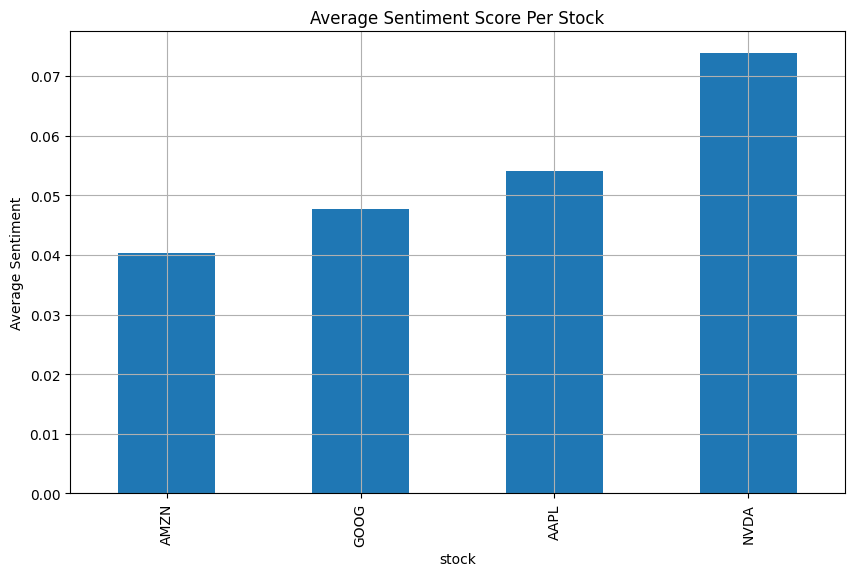

In [9]:
plt.figure(figsize=(10,6))

news.groupby("stock")["sentiment"].mean().sort_values().plot(kind="bar")

plt.title("Average Sentiment Score Per Stock")
plt.ylabel("Average Sentiment")

plt.grid(True)

plt.savefig("../notebooks/outputs/average_sentiment_per_stock.png")

plt.show()